<a href="https://colab.research.google.com/github/Danielbarz/analisis-sentimen-padel/blob/main/UTS_Pre-Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install & Import Libraries

In [2]:
!pip install openpyxl pandas nltk PySastrawi scikit-learn -q
import nltk
nltk.download('punkt')
nltk.download('stopwords')

import pandas as pd
import numpy as np
import re
import os
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('Libraries ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Libraries ready.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 2. Load Data dari File Excel Hasil Scraping

In [3]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[filename]), engine='openpyxl')
print(f'Data loaded: {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Kolom: {list(df.columns)}')
df.head(3)

Saving Padel_AI_Hybrid.xlsx to Padel_AI_Hybrid.xlsx
Data loaded: 789 baris x 10 kolom
Kolom: ['judul', 'url', 'sumber', 'tanggal', 'keyword', 'metode_scraping', 'konten', 'konten_bersih', 'teks_analisis', 'label']


,judul,url,sumber,tanggal,keyword,metode_scraping,konten,konten_bersih,teks_analisis,label
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",https://news.google.com/rss/articles/CBMixgFBV...,CNN Indonesia,2026-01-26 08:00:00,padel trend Indonesia,google_news_180d,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapangan pade...,riset laju properti 2026 moderat lapangan pade...,1
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,https://news.google.com/rss/articles/CBMiowFBV...,Bloomberg Technoz,2026-02-28 08:00:00,padel,google_news_180d,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,berapa biaya bangun lapangan padel ini rincian...,berapa biaya bangun lapangan padel ini rincian...,1
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",https://news.google.com/rss/articles/CBMiYkFVX...,RRI.co.id,2026-02-06 08:00:00,komunitas padel,google_news_180d,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapangan padel rooftop pertama di ...,maple padel lapangan padel rooftop pertama di ...,1


## 3. Inspeksi Awal & Statistik Data

In [4]:
print(f'Total artikel      : {len(df)}')
print(f'Kolom kosong:\n{df.isnull().sum().to_string()}')
print(f'\nDistribusi label:\n{df["label"].value_counts().to_string()}')
print(f'\nKonten kosong      : {(df["konten"].isna() | (df["konten"] == "")).sum()}')
print(f'Teks analisis kosong: {(df["teks_analisis"].isna() | (df["teks_analisis"] == "")).sum()}')

Total artikel      : 789
Kolom kosong:
judul                0
url                  0
sumber               0
tanggal            138
keyword              0
metode_scraping      0
konten               8
konten_bersih        8
teks_analisis        0
label                0

Distribusi label:
label
1    711
2     70
0      8

Konten kosong      : 8
Teks analisis kosong: 0


## 4. Pembersihan HTML, URL, dan Whitespace

In [5]:
def clean_basic(text):
    if not text or pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'<[^>]+>', '', text)            # hapus tag HTML
    text = re.sub(r'&[a-z]+;', ' ', text)          # hapus HTML entities: &nbsp; &amp; dll
    text = re.sub(r'http\S+|www\.\S+', '', text)   # hapus URL
    text = re.sub(r'\s+', ' ', text)               # normalize whitespace
    return text.strip()

df['konten_clean'] = df['konten'].apply(clean_basic)
df['judul_clean'] = df['judul'].apply(clean_basic)

print('HTML, URL, whitespace cleaned.')
print(df[['judul', 'judul_clean']].head(3).to_string())

HTML, URL, whitespace cleaned.
                                                                                judul                                                                         judul_clean
0  Riset: Laju Properti 2026 Moderat, Lapangan Padel Justru Meningkat - CNN Indonesia  Riset: Laju Properti 2026 Moderat, Lapangan Padel Justru Meningkat - CNN Indonesia
1              Berapa Biaya Bangun Lapangan Padel? Ini Rinciannya - Bloomberg Technoz              Berapa Biaya Bangun Lapangan Padel? Ini Rinciannya - Bloomberg Technoz
2                   Maple Padel, Lapangan Padel Rooftop Pertama di Jateng - RRI.co.id                   Maple Padel, Lapangan Padel Rooftop Pertama di Jateng - RRI.co.id


## 5. Normalisasi Teks (Lowercase, Strip, Hapus Non-Alfanumerik)

In [6]:
def normalize(text):
    if not text:
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)   # hapus non-alfanumerik
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['konten_norm'] = df['konten_clean'].apply(normalize)
df['judul_norm'] = df['judul_clean'].apply(normalize)

print('Normalisasi selesai.')
print(df[['judul_clean', 'judul_norm']].head(3).to_string())

Normalisasi selesai.
                                                                          judul_clean                                                                      judul_norm
0  Riset: Laju Properti 2026 Moderat, Lapangan Padel Justru Meningkat - CNN Indonesia  riset laju properti 2026 moderat lapangan padel justru meningkat cnn indonesia
1              Berapa Biaya Bangun Lapangan Padel? Ini Rinciannya - Bloomberg Technoz             berapa biaya bangun lapangan padel ini rinciannya bloomberg technoz
2                   Maple Padel, Lapangan Padel Rooftop Pertama di Jateng - RRI.co.id                    maple padel lapangan padel rooftop pertama di jateng rricoid


## 6. Drop Artikel Tanpa Konten

In [7]:
before = len(df)
df = df[df['konten_norm'] != ''].reset_index(drop=True)
print(f'Dropped : {before - len(df)} artikel tanpa konten')
print(f'Sisa    : {len(df)} artikel')

Dropped : 8 artikel tanpa konten
Sisa    : 781 artikel


## 7. Tokenisasi Teks (word_tokenize per token)

In [8]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [9]:
def tokenize(text):
    if not text:
        return []
    return word_tokenize(text)   # hapus language='indonesian'

df['tokens'] = df['konten_norm'].apply(tokenize)

print('Tokenisasi selesai.')
print(f'Rata-rata token per artikel: {df["tokens"].apply(len).mean():.0f}')
print(f'Contoh token:\n{df["tokens"].iloc[0][:20]}')

Tokenisasi selesai.
Rata-rata token per artikel: 71
Contoh token:
['riset', 'laju', 'properti', '2026', 'moderat', 'lapangan', 'padel', 'justru', 'meningkat', 'cnn', 'indonesia']


## 8. Stopword Removal (Bahasa Indonesia + Custom List)


cek kata frekuensi tinggi yang tidak bermakna

In [10]:
from collections import Counter

all_tokens = [t for tokens in df['tokens'] for t in tokens]
freq = Counter(all_tokens).most_common(50)

import pandas as pd
pd.DataFrame(freq, columns=['kata', 'frekuensi'])

,kata,frekuensi
0,padel,1945
1,yang,1414
2,di,1325
3,dan,1158
4,lapangan,817
5,ini,639
6,untuk,585
7,dengan,568
8,olahraga,537
9,dari,431


In [11]:
base_stopwords = set(stopwords.words('indonesian'))

custom_stopwords = {
    # noise HTML & portal
    'nbsp', 'scroll', 'continue', 'content', 'advertisement',
    'detikers', 'kompascom', 'detikcom', 'rricoid', 'sindonews',
    'tvonenews', 'gambas', 'video', 'detik', 'artikel', 'baca',
    # kata umum tidak bermakna untuk sentimen (dari hasil freq check)
    'yang', 'di', 'dan', 'ini', 'untuk', 'dengan', 'dari', 'juga',
    'itu', 'dalam', 'lebih', 'ada', 'bisa', 'tidak', 'menjadi',
    'hingga', 'pada', 'jadi', 'akan', 'bagi', 'saat', 'karena',
    'sudah', 'mulai', 'sebagai', 'tersebut', 'atau', 'ke', 'satu',
    'dapat', 'hanya', 'tak', 'tetap', 'seperti',
}

all_stopwords = base_stopwords.union(custom_stopwords)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 2]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

print('Stopword removal selesai.')
print(f'Rata-rata token setelah removal: {df["tokens_clean"].apply(len).mean():.0f}')

Stopword removal selesai.
Rata-rata token setelah removal: 43


## 9. Stemming (PySastrawi - Normalisasi Kata Bahasa Indonesia)

In [12]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

df['tokens_stemmed'] = df['tokens_clean'].apply(stem_tokens)
df['konten_stemmed'] = df['tokens_stemmed'].apply(lambda t: ' '.join(t))

df[['konten_norm', 'tokens_clean', 'tokens_stemmed', 'konten_stemmed']].head(3)

,konten_norm,tokens_clean,tokens_stemmed,konten_stemmed
0,riset laju properti 2026 moderat lapangan pade...,"[riset, laju, properti, 2026, moderat, lapanga...","[riset, laju, properti, 2026, moderat, lapang,...",riset laju properti 2026 moderat lapang padel ...
1,berapa biaya bangun lapangan padel ini rincian...,"[biaya, bangun, lapangan, padel, rinciannya, b...","[biaya, bangun, lapang, padel, rinciannya, blo...",biaya bangun lapang padel rinciannya bloomberg...
2,maple padel lapangan padel rooftop pertama di ...,"[maple, padel, lapangan, padel, rooftop, jateng]","[maple, padel, lapang, padel, rooftop, jateng]",maple padel lapang padel rooftop jateng


## 10. POS Tagging (NLTK - tag: NN, VB, JJ, dll)

In [13]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def pos_tag_tokens(tokens):
    return nltk.pos_tag(tokens)

df['pos_tags'] = df['tokens_clean'].apply(pos_tag_tokens)

df[['judul', 'tokens_clean', 'pos_tags']].head(3)

,judul,tokens_clean,pos_tags
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...","[riset, laju, properti, 2026, moderat, lapanga...","[(riset, NN), (laju, NN), (properti, NN), (202..."
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,"[biaya, bangun, lapangan, padel, rinciannya, b...","[(biaya, NN), (bangun, NN), (lapangan, JJ), (p..."
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...","[maple, padel, lapangan, padel, rooftop, jateng]","[(maple, JJ), (padel, NN), (lapangan, JJ), (pa..."


## 11. TF-IDF Vectorization (TfidfVectorizer sklearn - fitur analisis dan baseline)

In [14]:
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
tfidf_matrix = tfidf.fit_transform(df['konten_stemmed'])

df['tfidf_vector'] = list(tfidf_matrix.toarray())

feature_names = tfidf.get_feature_names_out()
tfidf_preview = pd.DataFrame(
    tfidf_matrix.toarray()[:5],
    columns=feature_names
)
tfidf_preview.iloc[:, :10]

,0600,088,0900,092,100,1000,105,10x20,110,1112
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
top_words = []
for i in range(5):
    row = tfidf_matrix.getrow(i)
    top_idx = row.toarray()[0].argsort()[::-1][:5]
    words = [(feature_names[j], round(tfidf_matrix[i, j], 4)) for j in top_idx if tfidf_matrix[i, j] > 0]
    top_words.append({'artikel': df['judul'].iloc[i][:40], 'top_kata': words})

pd.DataFrame(top_words)

,artikel,top_kata
0,"Riset: Laju Properti 2026 Moderat, Lapan","[(riset, 0.4751), (laju, 0.4542), (properti, 0..."
1,Berapa Biaya Bangun Lapangan Padel? Ini,"[(rinciannya, 0.554), (bloomberg, 0.4613), (te..."
2,"Maple Padel, Lapangan Padel Rooftop Pert","[(rooftop, 0.7774), (jateng, 0.5982), (lapang,..."
3,Pramono Resmi Larang Pembangunan Lapanga,"[(zona, 0.448), (cnn, 0.4385), (larang, 0.3975..."
4,Baru Pertama Main Padel? Ini Cara Bermai,"[(main, 0.5218), (ajar, 0.2992), (dasar, 0.294..."


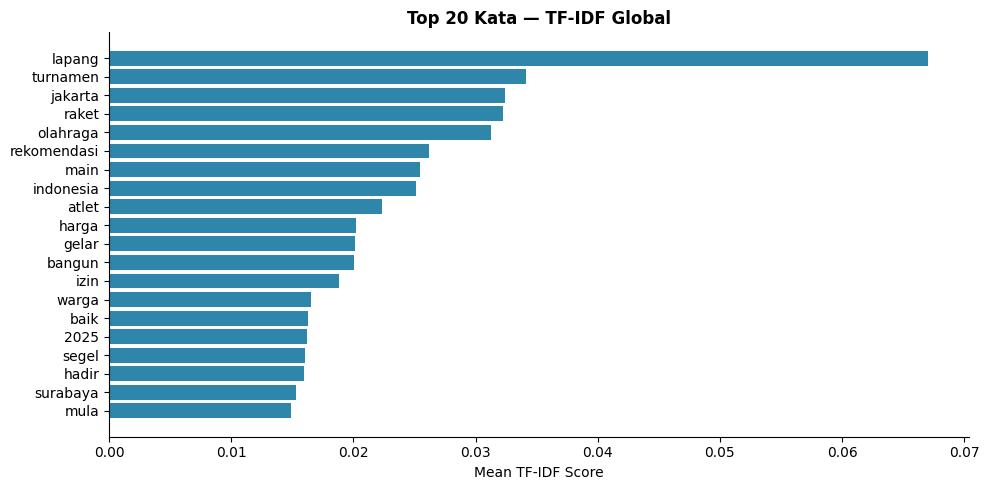

       kata    tfidf
     lapang 0.066998
   turnamen 0.034090
    jakarta 0.032427
      raket 0.032274
   olahraga 0.031251
rekomendasi 0.026160
       main 0.025477
  indonesia 0.025120
      atlet 0.022359
      harga 0.020243
      gelar 0.020151
     bangun 0.020085
       izin 0.018845
      warga 0.016564
       baik 0.016301
       2025 0.016182
      segel 0.016032
      hadir 0.015958
   surabaya 0.015298
       mula 0.014911


In [17]:
import matplotlib.pyplot as plt

scores_global = tfidf_matrix.mean(axis=0).A1
top_idx       = scores_global.argsort()[::-1][:20]
top_words_global = pd.DataFrame({
    'kata'  : feature_names[top_idx],
    'tfidf' : scores_global[top_idx]
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_words_global['kata'][::-1], top_words_global['tfidf'][::-1], color='#2E86AB')
ax.set_title('Top 20 Kata — TF-IDF Global', fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('tfidf_global.png', dpi=150)
plt.show()
print(top_words_global.to_string(index=False))

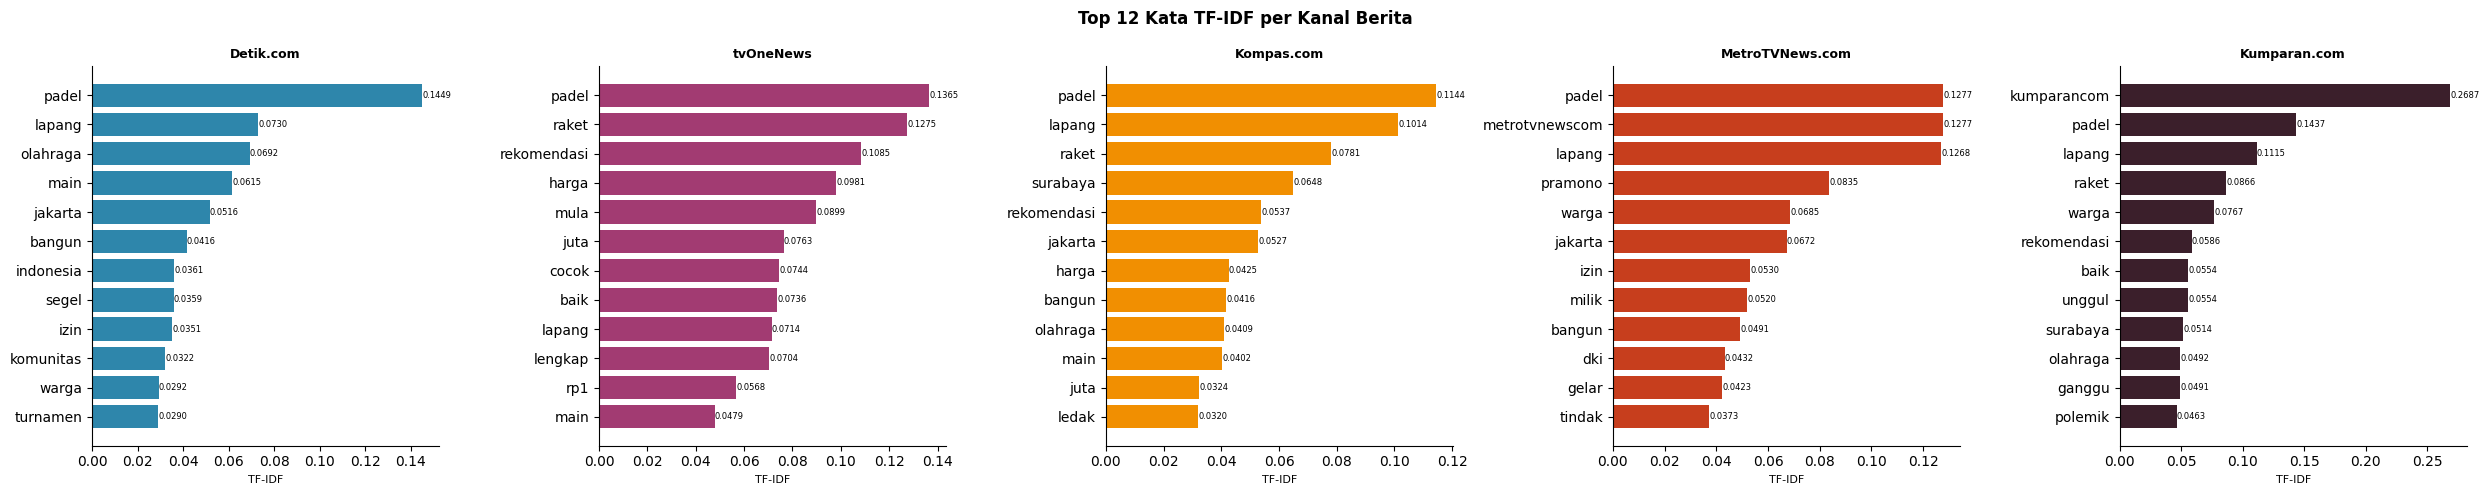

In [19]:
## 9. TF-IDF — Top Words per Kanal Berita

TEKS_COL = 'konten_stemmed'   # bukan 'teks_analisis'
top_sumber = df['sumber'].value_counts().head(5).index.tolist()
df_kanal   = df[df['sumber'].isin(top_sumber)].copy()

fig, axes = plt.subplots(1, len(top_sumber), figsize=(5 * len(top_sumber), 5), sharey=False)
COLORS = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#3B1F2B']

for ax, kanal, color in zip(axes, top_sumber, COLORS):
    subset = df_kanal[df_kanal['sumber'] == kanal][TEKS_COL].dropna()
    if len(subset) < 2:
        ax.set_title(kanal); continue
    tv = TfidfVectorizer(max_features=1000, min_df=1, ngram_range=(1,1))
    Xk = tv.fit_transform(subset)
    sc = Xk.mean(axis=0).A1
    idx = sc.argsort()[::-1][:12]
    words = tv.get_feature_names_out()[idx]
    bars  = ax.barh(words[::-1], sc[idx][::-1], color=color)
    ax.set_title(kanal[:30], fontsize=9, fontweight='bold')
    ax.set_xlabel('TF-IDF', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    for bar in bars:
        ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=6)

plt.suptitle('Top 12 Kata TF-IDF per Kanal Berita', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('tfidf_per_kanal.png', dpi=150, bbox_inches='tight')
plt.show()

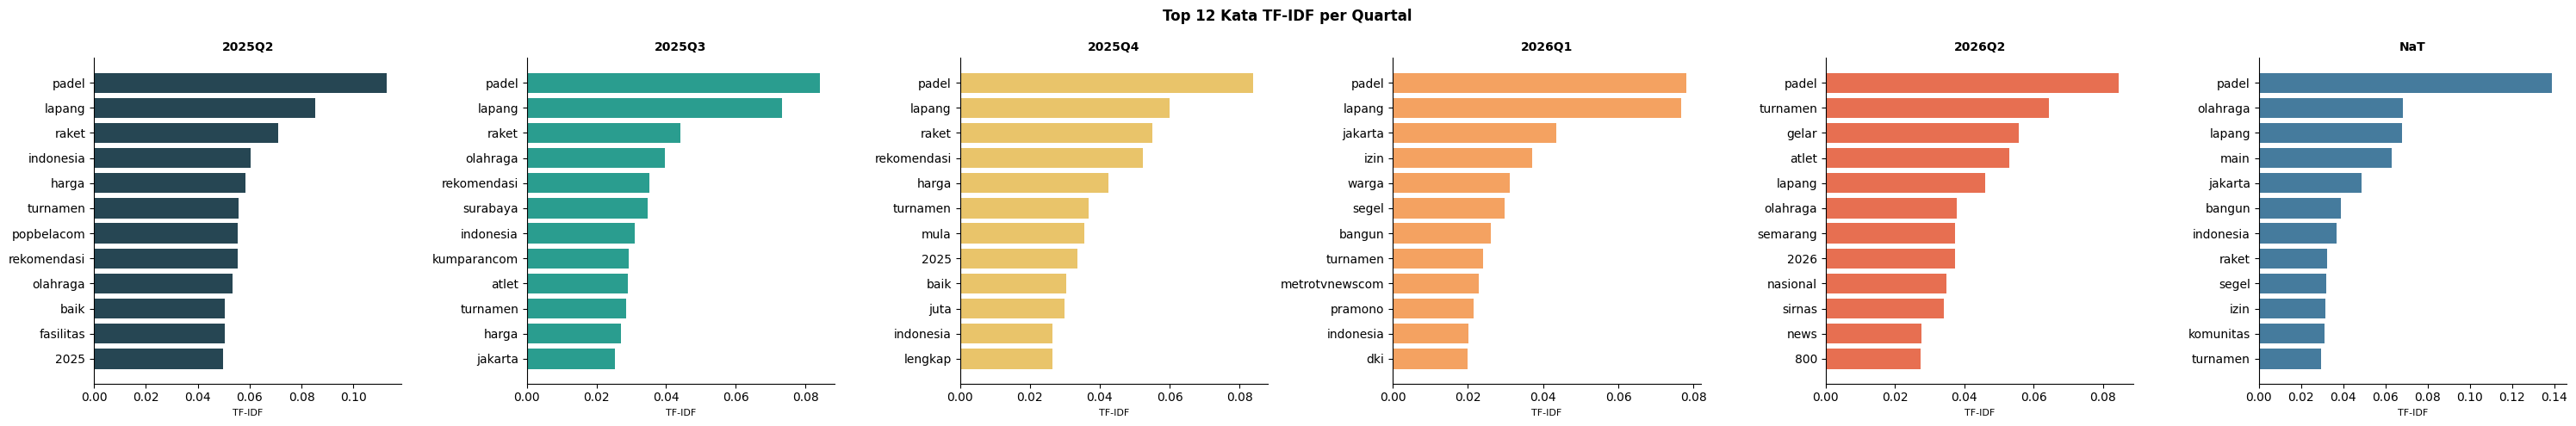

In [20]:
## 10. TF-IDF — Top Words per Time Frame (Quartal)

df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')
df['quartal'] = df['tanggal'].dt.to_period('Q').astype(str)

quartals = sorted(df['quartal'].dropna().unique())
fig, axes = plt.subplots(1, len(quartals), figsize=(5 * len(quartals), 5))
if len(quartals) == 1:
    axes = [axes]
COLORS_Q = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51','#457b9d']

for ax, q, color in zip(axes, quartals, COLORS_Q):
    subset = df[df['quartal'] == q][TEKS_COL].dropna()
    if len(subset) < 2:
        ax.set_title(q); continue
    tv = TfidfVectorizer(max_features=1000, min_df=1, ngram_range=(1,1))
    Xq = tv.fit_transform(subset)
    sc  = Xq.mean(axis=0).A1
    idx = sc.argsort()[::-1][:12]
    words = tv.get_feature_names_out()[idx]
    ax.barh(words[::-1], sc[idx][::-1], color=color)
    ax.set_title(q, fontweight='bold', fontsize=10)
    ax.set_xlabel('TF-IDF', fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Top 12 Kata TF-IDF per Quartal', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('tfidf_per_quartal.png', dpi=150, bbox_inches='tight')
plt.show()

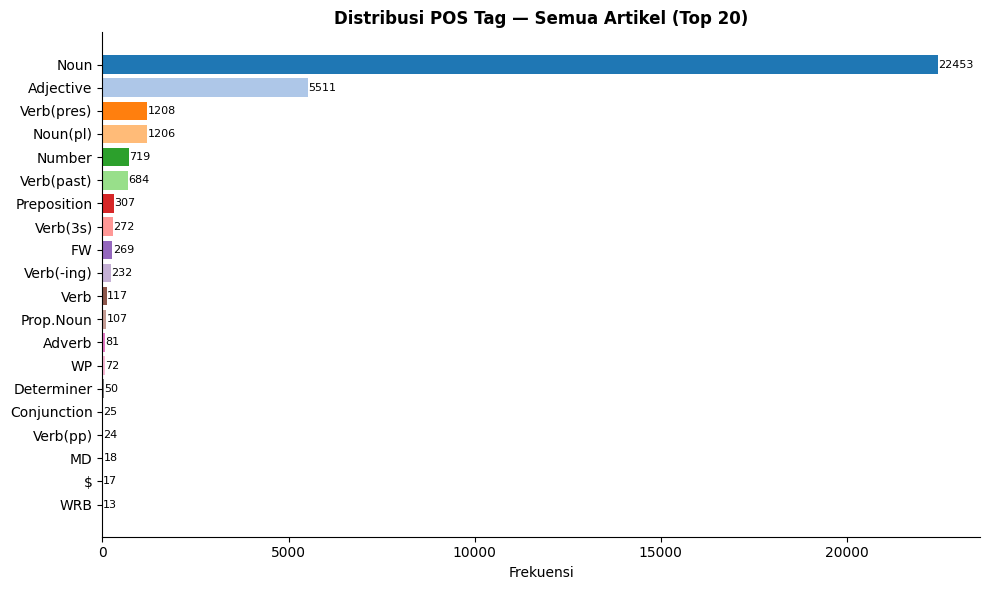

POS       Label  Count
 NN        Noun  22453
 JJ   Adjective   5511
VBP  Verb(pres)   1208
NNS    Noun(pl)   1206
 CD      Number    719
VBD  Verb(past)    684
 IN Preposition    307
VBZ    Verb(3s)    272
 FW          FW    269
VBG  Verb(-ing)    232
 VB        Verb    117
NNP   Prop.Noun    107
 RB      Adverb     81
 WP          WP     72
 DT  Determiner     50
 CC Conjunction     25
VBN    Verb(pp)     24
 MD          MD     18
  $           $     17
WRB         WRB     13


In [21]:
from collections import Counter

all_pos = []
for tag_list in df['pos_tags'].dropna():
    all_pos.extend([tag for _, tag in tag_list])

POS_LABELS = {
    'NN':'Noun','NNS':'Noun(pl)','NNP':'Prop.Noun','NNPS':'Prop.Noun(pl)',
    'VB':'Verb','VBD':'Verb(past)','VBG':'Verb(-ing)','VBN':'Verb(pp)','VBP':'Verb(pres)','VBZ':'Verb(3s)',
    'JJ':'Adjective','JJR':'Adj(comp)','JJS':'Adj(sup)',
    'RB':'Adverb','IN':'Preposition','CC':'Conjunction',
    'PRP':'Pronoun','CD':'Number','DT':'Determiner'
}

pos_counts = Counter(all_pos)
pos_df = pd.DataFrame([
    {'POS': tag, 'Label': POS_LABELS.get(tag, tag), 'Count': count}
    for tag, count in pos_counts.most_common(20)
])

fig, ax = plt.subplots(figsize=(10, 6))
colors_pos = plt.cm.tab20.colors[:len(pos_df)]
ax.barh(pos_df['Label'][::-1], pos_df['Count'][::-1], color=colors_pos[::-1])
for i, (_, row) in enumerate(pos_df[::-1].iterrows()):
    ax.text(row['Count'] + 5, i, str(int(row['Count'])), va='center', fontsize=8)
ax.set_title('Distribusi POS Tag — Semua Artikel (Top 20)', fontweight='bold')
ax.set_xlabel('Frekuensi')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('pos_analysis.png', dpi=150)
plt.show()
print(pos_df.to_string(index=False))

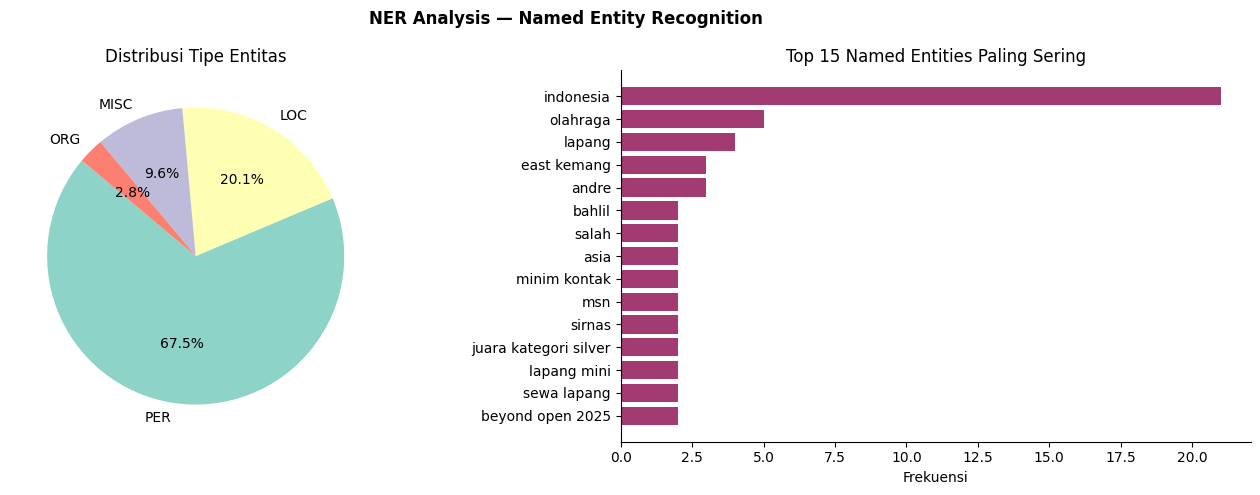


Top entities per type:
 label                  text  n
  LOC             indonesia 21
  LOC           east kemang  3
  LOC                  asia  2
  LOC                bahlil  2
  LOC              olahraga  2
 MISC              olahraga  3
 MISC      beyond open 2025  2
 MISC                   msn  2
 MISC           academy 520  1
 MISC         academy jalan  1
  ORG         cnn indonesia  1
  ORG             harga jam  1
  ORG               jpnncom  1
  ORG             menit jam  1
  ORG                   sos  1
  PER                lapang  4
  PER                 andre  3
  PER juara kategori silver  2
  PER           lapang mini  2
  PER          minim kontak  2


In [22]:
## 12. NER Analysis (Named Entity Recognition)

# Install spaCy model kecil (multi-language) — jalankan sekali
import subprocess
subprocess.run(['pip', 'install', 'spacy', '-q'])
subprocess.run(['python', '-m', 'spacy', 'download', 'xx_ent_wiki_sm', '-q'])

import spacy
nlp_ner = spacy.load('xx_ent_wiki_sm')

entities = []
for teks in df[TEKS_COL].dropna().sample(min(150, len(df)), random_state=42):
    doc = nlp_ner(str(teks)[:500])   # batasi 500 char per doc agar cepat
    for ent in doc.ents:
        entities.append({'text': ent.text, 'label': ent.label_})

ner_df = pd.DataFrame(entities)
if not ner_df.empty:
    ner_counts = ner_df['label'].value_counts().reset_index()
    ner_counts.columns = ['Entity Type', 'Count']

    top_per_type = (
        ner_df.groupby(['label','text'])
              .size().reset_index(name='n')
              .sort_values(['label','n'], ascending=[True, False])
              .groupby('label').head(5)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('NER Analysis — Named Entity Recognition', fontweight='bold')

    # Pie chart distribusi tipe entitas
    axes[0].pie(ner_counts['Count'], labels=ner_counts['Entity Type'],
                autopct='%1.1f%%', startangle=140,
                colors=plt.cm.Set3.colors[:len(ner_counts)])
    axes[0].set_title('Distribusi Tipe Entitas')

    # Top 15 entitas paling sering
    top15 = ner_df['text'].value_counts().head(15).reset_index()
    top15.columns = ['Entitas', 'Count']
    axes[1].barh(top15['Entitas'][::-1], top15['Count'][::-1], color='#A23B72')
    axes[1].set_title('Top 15 Named Entities Paling Sering')
    axes[1].set_xlabel('Frekuensi')
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('ner_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nTop entities per type:\n', top_per_type.to_string(index=False))
else:
    print('Tidak ada entitas yang terdeteksi.')

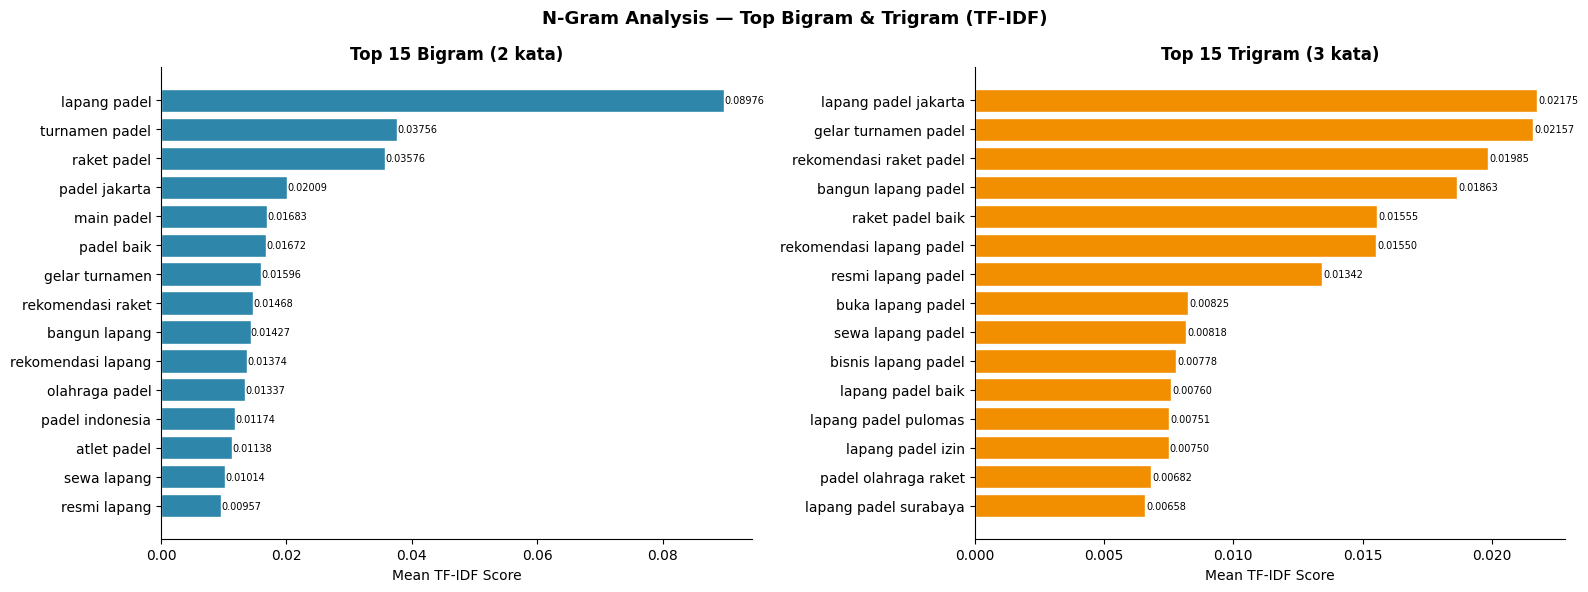


=== Top Bigram per Label Sentimen ===
  Negatif: ['gudang vivacoid', 'industri padel', 'main padel', 'servis padel', 'cair mineral']
  Netral: ['lapang padel', 'raket padel', 'turnamen padel', 'padel jakarta', 'padel baik']
  Positif: ['turnamen padel', 'lapang padel', 'main padel', 'sukses gelar', 'padel indonesia']


In [23]:
## 13. N-Gram Analysis (Bigram & Trigram)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('N-Gram Analysis — Top Bigram & Trigram (TF-IDF)', fontweight='bold', fontsize=13)

for ax, n, title, color in zip(
    axes,
    [2, 3],
    ['Top 15 Bigram (2 kata)', 'Top 15 Trigram (3 kata)'],
    ['#2E86AB', '#F18F01']
):
    tv_ng = TfidfVectorizer(max_features=3000, min_df=2, ngram_range=(n, n))
    Xng   = tv_ng.fit_transform(df[TEKS_COL].fillna(''))
    sc_ng = Xng.mean(axis=0).A1
    idx   = sc_ng.argsort()[::-1][:15]
    words = tv_ng.get_feature_names_out()[idx]
    scores = sc_ng[idx]

    bars = ax.barh(words[::-1], scores[::-1], color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width() + 0.00005, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.5f}', va='center', fontsize=7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Tambahan: Bigram per label sentimen
print('\n=== Top Bigram per Label Sentimen ===')
label_map = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
for lbl, lbl_name in label_map.items():
    subset = df[df['label'] == lbl][TEKS_COL].fillna('')
    if len(subset) < 3: continue
    tv2 = TfidfVectorizer(max_features=500, min_df=1, ngram_range=(2,2))
    X2  = tv2.fit_transform(subset)
    sc2 = X2.mean(axis=0).A1
    top5 = tv2.get_feature_names_out()[sc2.argsort()[::-1][:5]]
    print(f'  {lbl_name}: {list(top5)}')

## 12. Pemetaan Label & Split Data (Train 80% / Val 10% / Test 10%)
Label: 0 = Negatif, 1 = Netral, 2 = Positif

In [24]:
df['label'] = pd.to_numeric(df['label'], errors='coerce').fillna(1).astype(int)
df = df[df['label'].isin([0, 1, 2])].reset_index(drop=True)

label_map = {0: 'negatif', 1: 'netral', 2: 'positif'}
df['label_text'] = df['label'].map(label_map)

X = df['konten_stemmed']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

df[['judul', 'label', 'label_text']].head(5)

Train : 624 | Val : 78 | Test : 79


,judul,label,label_text
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",1,netral
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,1,netral
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",1,netral
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,1,netral
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,2,positif


## 13. Output DataFrame Final
Kolom: konten_bersih, pos_tags, tfidf_vector, label

In [25]:
cols_output = [
    'judul', 'url', 'sumber', 'tanggal', 'keyword', 'metode_scraping',
    'konten', 'konten_norm', 'konten_stemmed', 'tokens_clean',
    'pos_tags', 'tfidf_vector', 'label', 'label_text'
]

df_final = df[cols_output].copy()

ts = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
os.makedirs('data', exist_ok=True)

df_final.drop(columns=['tfidf_vector', 'pos_tags', 'tokens_clean']).to_csv(
    f'data/padel_preprocessed_{ts}.csv', index=False, encoding='utf-8-sig'
)
df_final.drop(columns=['tfidf_vector', 'pos_tags', 'tokens_clean']).to_excel(
    f'data/padel_preprocessed_{ts}.xlsx', index=False
)

print(f'Saved  : data/padel_preprocessed_{ts}.csv')
print(f'Total  : {len(df_final)} artikel')

df_final[['judul', 'konten_stemmed', 'label', 'label_text']].head(5)

Saved  : data/padel_preprocessed_20260506_010427.csv
Total  : 781 artikel


,judul,konten_stemmed,label,label_text
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapang padel ...,1,netral
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,biaya bangun lapang padel rinciannya bloomberg...,1,netral
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapang padel rooftop jateng,1,netral
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,pramono resmi larang bangun lapang padel zona ...,1,netral
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,padel olahraga viral gari indonesia cinta olah...,2,positif
